# Resume Screening: Format-Bias Robustness Study
### Deep Learning Component — DistilBERT Fine-Tuning (+ TF-IDF/SVM baseline for comparison)

This notebook covers **Steps 1–2 and part of Step 5** of the project workflow:
- Load & preprocess the Kaggle Resume Dataset
- Train the classical baseline (TF-IDF + SVM)
- Fine-tune DistilBERT for resume category classification
- Evaluate both (accuracy, F1, confusion matrix)

> Run cells top to bottom. If `transformers`/`datasets`/`torch` aren't installed, run the install cell below first.


In [1]:
# Install dependencies (skip if already installed)
import sys
!{sys.executable} -m pip install -q transformers datasets torch scikit-learn pandas matplotlib seaborn
!{sys.executable} -m pip install -U -q "accelerate>=1.1.0"

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: mps


## 1. Load Dataset

Point `DATA_PATH` at your Kaggle Resume Dataset CSV (commonly named `UpdatedResumeDataSet.csv`,
columns: `Category`, `Resume`). Download it from Kaggle and set the path below.

If the file isn't found, this cell falls back to a **small synthetic dataset** so you can run the
full pipeline end-to-end tonight to confirm everything works — swap in the real CSV before your
final submission/results.


In [2]:
DATA_PATH = "UpdatedResumeDataSet.csv"  # <-- change this to your actual Kaggle CSV path

def load_synthetic_fallback(n_per_category=40):
    """Small synthetic dataset for pipeline testing only. NOT for final results."""
    categories = {
        "Data Science": [
            "Experienced in Python, pandas, scikit-learn, and building machine learning models for predictive analytics.",
            "Worked on deep learning projects using TensorFlow and PyTorch, including CNNs and NLP pipelines.",
            "Strong background in statistics, data visualization, and SQL for data-driven decision making.",
        ],
        "HR": [
            "Managed recruitment cycles, employee onboarding, and performance review processes.",
            "Experienced in HR policy development, payroll coordination, and employee engagement programs.",
            "Handled talent acquisition, conflict resolution, and compliance with labor regulations.",
        ],
        "Web Developer": [
            "Built responsive web applications using React, Node.js, and REST APIs.",
            "Experienced with HTML, CSS, JavaScript, and modern frontend frameworks like Vue and Angular.",
            "Worked on full-stack development including databases, authentication, and deployment pipelines.",
        ],
        "Mechanical Engineer": [
            "Designed and tested mechanical components using SolidWorks and AutoCAD.",
            "Experience in thermodynamics, fluid mechanics, and manufacturing process optimization.",
            "Worked on CNC machining, quality control, and product lifecycle management.",
        ],
        "Sales": [
            "Managed key client accounts, exceeded quarterly sales targets, and built long-term relationships.",
            "Experienced in B2B sales, lead generation, and CRM tools like Salesforce.",
            "Skilled in negotiation, market research, and territory expansion strategies.",
        ],
    }
    rows = []
    for cat, templates in categories.items():
        for i in range(n_per_category):
            base = templates[i % len(templates)]
            rows.append({"Category": cat, "Resume": f"{base} Additional detail item {i}."})
    return pd.DataFrame(rows)

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    # normalize expected column names
    col_map = {c.lower(): c for c in df.columns}
    text_col = col_map.get("resume") or col_map.get("resume_str") or col_map.get("text")
    label_col = col_map.get("category") or col_map.get("label")
    df = df[[label_col, text_col]].rename(columns={label_col: "Category", text_col: "Resume"})
    print(f"Loaded real dataset: {len(df)} rows, {df['Category'].nunique()} categories")
else:
    print(f"'{DATA_PATH}' not found — using SYNTHETIC fallback data for pipeline testing.")
    df = load_synthetic_fallback()
    print(f"Synthetic dataset: {len(df)} rows, {df['Category'].nunique()} categories")

df = df.dropna(subset=["Category", "Resume"]).reset_index(drop=True)
df.head()


Loaded real dataset: 962 rows, 25 categories


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


## 2. Preprocessing

In [3]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)          # URLs
    text = re.sub(r"[^A-Za-z0-9\s.,;:()/#+-]", " ", text)  # strip weird symbols
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["Resume"].apply(clean_text)

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Category"])
num_labels = df["label"].nunique()
print("Categories:", list(label_encoder.classes_))
print("Num labels:", num_labels)


Categories: ['Advocate', 'Arts', 'Automation Testing', 'Blockchain', 'Business Analyst', 'Civil Engineer', 'Data Science', 'Database', 'DevOps Engineer', 'DotNet Developer', 'ETL Developer', 'Electrical Engineering', 'HR', 'Hadoop', 'Health and fitness', 'Java Developer', 'Mechanical Engineer', 'Network Security Engineer', 'Operations Manager', 'PMO', 'Python Developer', 'SAP Developer', 'Sales', 'Testing', 'Web Designing']
Num labels: 25


## 3. Train / Test Split

We also carve out a **held-out set** here — this is the set you'll later render into messy PDF
layouts (Step 3 of the project) and re-extract text from (Step 4) to measure the accuracy drop
under formatting stress (Step 5). For now it's just a clean held-out split.


In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["label"]
)
test_df, heldout_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

print("Train:", len(train_df), "| Test:", len(test_df), "| Held-out (for formatting stress test):", len(heldout_df))

# Save held-out set with ground-truth text for the later synthetic-messy-resume step
heldout_df.to_csv("heldout_ground_truth.csv", index=False)


Train: 673 | Test: 144 | Held-out (for formatting stress test): 145


## 4. Baseline — TF-IDF + Linear SVM

In [5]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_train_tfidf = tfidf.fit_transform(train_df["clean_text"])
X_test_tfidf = tfidf.transform(test_df["clean_text"])

svm_clf = LinearSVC(random_state=SEED)
svm_clf.fit(X_train_tfidf, train_df["label"])

svm_preds = svm_clf.predict(X_test_tfidf)

svm_acc = accuracy_score(test_df["label"], svm_preds)
svm_f1 = f1_score(test_df["label"], svm_preds, average="weighted")

print(f"[TF-IDF + SVM]  Accuracy: {svm_acc:.4f}  |  Weighted F1: {svm_f1:.4f}")
print(classification_report(test_df["label"], svm_preds, target_names=label_encoder.classes_, zero_division=0))


[TF-IDF + SVM]  Accuracy: 0.9931  |  Weighted F1: 0.9932
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         5
       Automation Testing       0.80      1.00      0.89         4
               Blockchain       1.00      1.00      1.00         6
         Business Analyst       1.00      1.00      1.00         4
           Civil Engineer       1.00      1.00      1.00         4
             Data Science       1.00      1.00      1.00         6
                 Database       1.00      1.00      1.00         5
          DevOps Engineer       1.00      0.88      0.93         8
         DotNet Developer       1.00      1.00      1.00         4
            ETL Developer       1.00      1.00      1.00         6
   Electrical Engineering       1.00      1.00      1.00         5
                       HR       1.00      1.00      1.00         6
    

## 5. Deep Learning — Fine-Tune DistilBERT

This is the core deep learning component: transfer learning via fine-tuning a pretrained
transformer (`distilbert-base-uncased`) for multi-class resume classification.


In [6]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256  # reduce to 128 for a faster CPU demo run

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ResumeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = ResumeDataset(train_df["clean_text"], train_df["label"], tokenizer)
test_dataset = ResumeDataset(test_df["clean_text"], test_df["label"], tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
model.to(DEVICE)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

training_args = TrainingArguments(
    output_dir="./distilbert_resume_ckpt",
    num_train_epochs=4,             # bump to 6-8 once on real data / GPU
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    logging_steps=10,
    report_to=[],                    # disable wandb/etc for a clean run
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,2.910395,2.739618,0.381944,0.318125
2,2.148847,1.997485,0.833333,0.803869
3,1.626565,1.540111,0.930556,0.921464
4,1.421661,1.392566,0.951389,0.944612


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=340, training_loss=2.203501174029182, metrics={'train_runtime': 160.0314, 'train_samples_per_second': 16.822, 'train_steps_per_second': 2.125, 'total_flos': 178374252779520.0, 'train_loss': 2.203501174029182, 'epoch': 4.0})

## 6. Evaluate DistilBERT vs. Baseline

In [8]:
bert_eval = trainer.evaluate()
print("DistilBERT eval metrics:", bert_eval)

bert_preds_output = trainer.predict(test_dataset)
bert_preds = np.argmax(bert_preds_output.predictions, axis=1)

bert_acc = accuracy_score(test_df["label"], bert_preds)
bert_f1 = f1_score(test_df["label"], bert_preds, average="weighted")

print(f"\n[DistilBERT]     Accuracy: {bert_acc:.4f}  |  Weighted F1: {bert_f1:.4f}")
print(f"[TF-IDF + SVM]   Accuracy: {svm_acc:.4f}  |  Weighted F1: {svm_f1:.4f}")

comparison_df = pd.DataFrame({
    "Model": ["TF-IDF + SVM", "DistilBERT (fine-tuned)"],
    "Accuracy": [svm_acc, bert_acc],
    "Weighted F1": [svm_f1, bert_f1],
})
comparison_df


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted
1.421661,1.392566,4,0.951389,0.944612


DistilBERT eval metrics: {'eval_loss': 1.392566204071045, 'eval_accuracy': 0.9513888888888888, 'eval_f1_weighted': 0.9446123321123322}


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



[DistilBERT]     Accuracy: 0.9514  |  Weighted F1: 0.9446
[TF-IDF + SVM]   Accuracy: 0.9931  |  Weighted F1: 0.9932


,Model,Accuracy,Weighted F1
0,TF-IDF + SVM,0.993056,0.993210
1,DistilBERT (fine-tuned),0.951389,0.944612


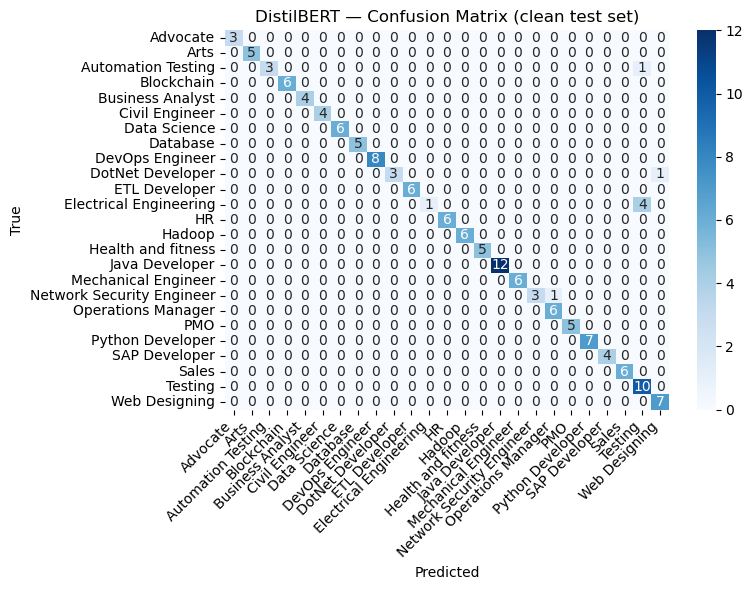

In [9]:
# Confusion matrix for DistilBERT
cm = confusion_matrix(test_df["label"], bert_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DistilBERT — Confusion Matrix (clean test set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("distilbert_confusion_matrix.png", dpi=150)
plt.show()


## 7. Save the Fine-Tuned Model

Saves locally so it can be reloaded for Step 5 (classification under formatting stress) once
the synthetic messy-resume pipeline (Steps 3–4) is built.


In [10]:
SAVE_DIR = "./distilbert_resume_finetuned"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Model + tokenizer saved to {SAVE_DIR}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model + tokenizer saved to ./distilbert_resume_finetuned


---
### Next steps (for the full cross-disciplinary study, not needed for tomorrow)
1. **Step 3** — Use `reportlab` to render `heldout_ground_truth.csv` resumes into 4 layout conditions.
2. **Step 4** — Extract text back out with `pdfplumber`/`PyMuPDF`, compute edit-distance degradation scores.
3. **Step 5** — Reload this saved DistilBERT model + the TF-IDF/SVM model, run both on the degraded text, compare accuracy drop.
4. **Step 7** — Layout-aware extraction mitigation using PyMuPDF block detection.
